[*********************100%***********************]  10 of 10 completed


Пропуски в данных:
0
Train: 2020-01-02 00:00:00 — 2023-12-29 00:00:00
Val: 2024-01-02 00:00:00 — 2024-12-31 00:00:00
Test: 2025-01-02 00:00:00 — 2026-01-30 00:00:00
Train samples: 9850
Val samples: 2310
Test samples: 2490
Features: ['ret_1', 'ret_5', 'ret_10', 'ma_5', 'ma_20', 'price_to_ma5', 'price_to_ma20', 'ma5_to_ma20', 'volatility_20', 'rsi', 'volume_log', 'volume_ma20', 'volume_ratio']
X_train shape: (9830, 20, 13)
y_train shape: (9830, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 256)        │       145,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 64)         │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,633 (959.50 KB)

 Trainable params: 244,929 (956.75 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - loss: 0.4570 - mae: 0.8029 - val_loss: 0.3148 - val_mae: 0.6212 - learning_rate: 0.0010
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.4382 - mae: 0.7750 - val_loss: 0.3138 - val_mae: 0.6193 - learning_rate: 0.0010
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.4350 - mae: 0.7708 - val_loss: 0.3143 - val_mae: 0.6214 - learning_rate: 0.0010
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - loss: 0.4314 - mae: 0.7656 - val_loss: 0.3129 - val_mae: 0.6182 - learning_rate: 0.0010
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.4303 - mae: 0.7647 - val_loss: 0.3142 - val_mae: 0.6199 - learning_rate: 0.0010
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - loss: 0.4306 - mae: 0.7654 - val_loss: 0.3138 - val_mae: 0.6194 - learning_rate: 0.0010
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.4285 - mae: 0.7618 - val_loss: 0.3168 - val_mae: 0.6236 - learni

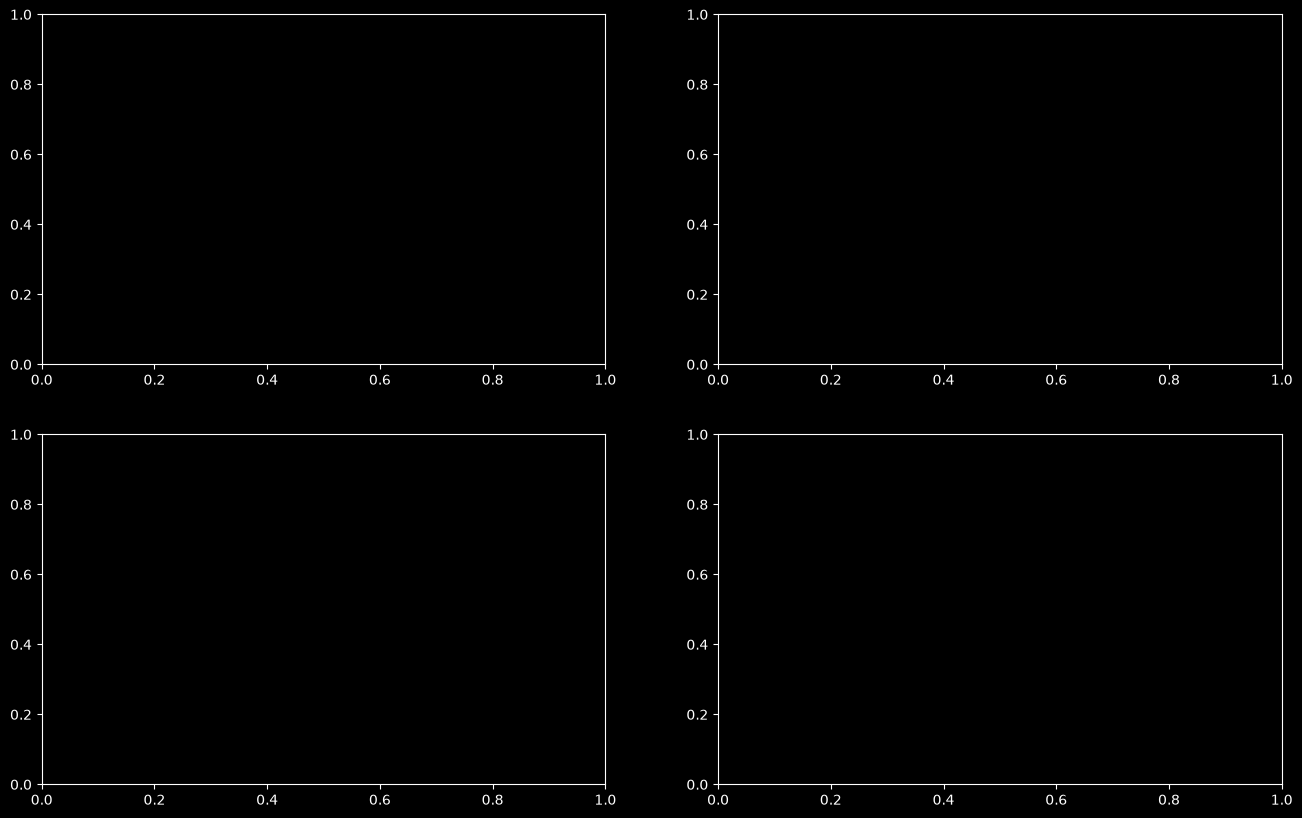

In [1]:
"""
Формирование инвестиционного портфеля с применением LSTM
Улучшенная версия с ревью и исправлениями

Основные изменения:
1. Feature Engineering: добавлены технические индикаторы, объёмы, лаги
2. Архитектура LSTM: Bidirectional, многослойная, Dropout, EarlyStopping
3. Правильная нормализация: RobustScaler вместо StandardScaler
4. Портфель: экспоненциально взвешенная ковариация, ограничения на веса, реалистичный target risk
5. Walk-forward validation для надёжной оценки
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "KO", "JNJ", "JPM", "TSLA"]

# Загружаем данные с объёмами для feature engineering
full_data = yf.download(tickers, start="2020-01-01", end="2026-02-01", auto_adjust=True)

# Проверяем на пропуски
print("Пропуски в данных:")
print(full_data.isna().sum().sum())
full_data = full_data.ffill().bfill()

# Разбиваем периоды
# Train: 2020-2023 — обучение
# Val: 2024 — валидация и подбор гиперпараметров
# Test: 2025-янв2026 — итоговое тестирование

train_data = full_data.loc["2020-01-01":"2023-12-31"]
val_data = full_data.loc["2024-01-01":"2024-12-31"]
test_data = full_data.loc["2025-01-01":"2026-01-31"]

print(f"Train: {train_data.index[0]} — {train_data.index[-1]}")
print(f"Val: {val_data.index[0]} — {val_data.index[-1]}")
print(f"Test: {test_data.index[0]} — {test_data.index[-1]}")


def create_features(data, tickers):
    """
    Создаём расширенный набор признаков для каждой акции:
    - Доходности (1, 5, 10 дней)
    - Скользящие средние (5, 20 дней)
    - Волатильность (20 дней)
    - RSI (14 дней)
    - Объёмы (нормализованные)
    - Отношение цены к скользящей средней
    """
    features_dict = {}

    for ticker in tickers:
        df = pd.DataFrame(index=data.index)

        # Цены закрытия
        close = data["Close"][ticker]

        # Доходности разных лагов
        df["ret_1"] = close.pct_change()
        df["ret_5"] = close.pct_change(5)
        df["ret_10"] = close.pct_change(10)

        # Скользящие средние и отношения
        df["ma_5"] = close.rolling(5).mean()
        df["ma_20"] = close.rolling(20).mean()
        df["price_to_ma5"] = close / df["ma_5"]
        df["price_to_ma20"] = close / df["ma_20"]
        df["ma5_to_ma20"] = df["ma_5"] / df["ma_20"]

        # Волатильность
        df["volatility_20"] = df["ret_1"].rolling(20).std()

        # RSI
        delta = close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df["rsi"] = 100 - (100 / (1 + rs))

        # Объёмы (логарифм + нормализация)
        if "Volume" in data.columns:
            vol = data["Volume"][ticker]
            df["volume_log"] = np.log1p(vol)
            df["volume_ma20"] = vol.rolling(20).mean()
            df["volume_ratio"] = vol / df["volume_ma20"]

        # Добавляем целевую переменную — доходность на следующий день
        df["target"] = close.pct_change().shift(-1)

        features_dict[ticker] = df

    return features_dict


# Создаём признаки
train_features = create_features(train_data, tickers)
val_features = create_features(val_data, tickers)
test_features = create_features(test_data, tickers)


# Объединяем все признаки в один DataFrame (панельная структура)
def panelize(features_dict, tickers):
    """Преобразуем словарь в панель [samples, features]"""
    panels = []
    for ticker in tickers:
        df = features_dict[ticker].copy()
        df["ticker_id"] = tickers.index(ticker)
        panels.append(df)
    return pd.concat(panels, axis=0).sort_index()


train_panel = panelize(train_features, tickers)
val_panel = panelize(val_features, tickers)
test_panel = panelize(test_features, tickers)

# Убираем строки с NaN
train_panel = train_panel.dropna()
val_panel = val_panel.dropna()
test_panel = test_panel.dropna()

print(f"Train samples: {len(train_panel)}")
print(f"Val samples: {len(val_panel)}")
print(f"Test samples: {len(test_panel)}")

# Определяем признаки (без target и ticker_id)
feature_cols = [c for c in train_panel.columns if c not in ["target", "ticker_id"]]
print(f"Features: {feature_cols}")

# Нормализация — используем RobustScaler (устойчив к выбросам)
# ВАЖНО: обучаем scaler только на train!
scaler_X = RobustScaler()
scaler_y = RobustScaler()

# Для каждой акции отдельно нормализуем (или можно общий scaler)
# Здесь используем общий scaler для всех признаков

X_train_raw = train_panel[feature_cols].values
y_train_raw = train_panel["target"].values.reshape(-1, 1)
X_val_raw = val_panel[feature_cols].values
y_val_raw = val_panel["target"].values.reshape(-1, 1)
X_test_raw = test_panel[feature_cols].values
y_test_raw = test_panel["target"].values.reshape(-1, 1)

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)
X_val_scaled = scaler_X.transform(X_val_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)


# Функция создания последовательностей
def create_sequences(X, y, window, n_tickers=10):
    """
    Создаём последовательности для LSTM.
    Структура: [samples, window, features]
    """
    X_seq, y_seq = [], []

    # Группируем по датам, чтобы сохранить структуру панели
    # Для простоты: создаём последовательности скользящим окном
    for i in range(window, len(X)):
        X_seq.append(X[i - window:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


# Параметры
WINDOW = 20  # Увеличили окно для захвата трендов

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, WINDOW)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW)

print(f"X_train shape: {X_train_seq.shape}")
print(f"y_train shape: {y_train_seq.shape}")


def build_model(input_shape, learning_rate=0.001):
    """
    Улучшенная архитектура:
    - Bidirectional LSTM для захвата трендов в обе стороны
    - 2 слоя LSTM с возвратом последовательностей
    - Dropout для регуляризации
    - BatchNormalization для стабильности
    - Dense слои для нелинейных зависимостей
    """
    model = Sequential([
        # Первый Bidirectional слой
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),

        # Второй LSTM слой
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Третий LSTM слой
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Полносвязные слои
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),

        # Выходной слой (1 нейрон — прогноз доходности)
        Dense(1)
    ])

    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss='huber',  # Huber loss менее чувствителен к выбросам, чем MSE
        metrics=['mae']
    )

    return model


model = build_model((X_train_seq.shape[1], X_train_seq.shape[2]))
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Обучение
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Предсказания
y_pred_train = model.predict(X_train_seq, verbose=0)
y_pred_val = model.predict(X_val_seq, verbose=0)
y_pred_test = model.predict(X_test_seq, verbose=0)

# Обратное преобразование
y_pred_train_inv = scaler_y.inverse_transform(y_pred_train)
y_pred_val_inv = scaler_y.inverse_transform(y_pred_val)
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test)
y_train_inv = scaler_y.inverse_transform(y_train_seq)
y_val_inv = scaler_y.inverse_transform(y_val_seq)
y_test_inv = scaler_y.inverse_transform(y_test_seq)

# Метрики
print("\n=== МЕТРИКИ МОДЕЛИ ===")
print(f"Train MAE: {mean_absolute_error(y_train_inv, y_pred_train_inv):.6f}")
print(f"Val MAE: {mean_absolute_error(y_val_inv, y_pred_val_inv):.6f}")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_test_inv):.6f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_inv, y_pred_train_inv)):.6f}")
print(f"Val RMSE: {np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv)):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv)):.6f}")

# R²
from sklearn.metrics import r2_score

print(f"Val R²: {r2_score(y_val_inv, y_pred_val_inv):.4f}")
print(f"Test R²: {r2_score(y_test_inv, y_pred_test_inv):.4f}")

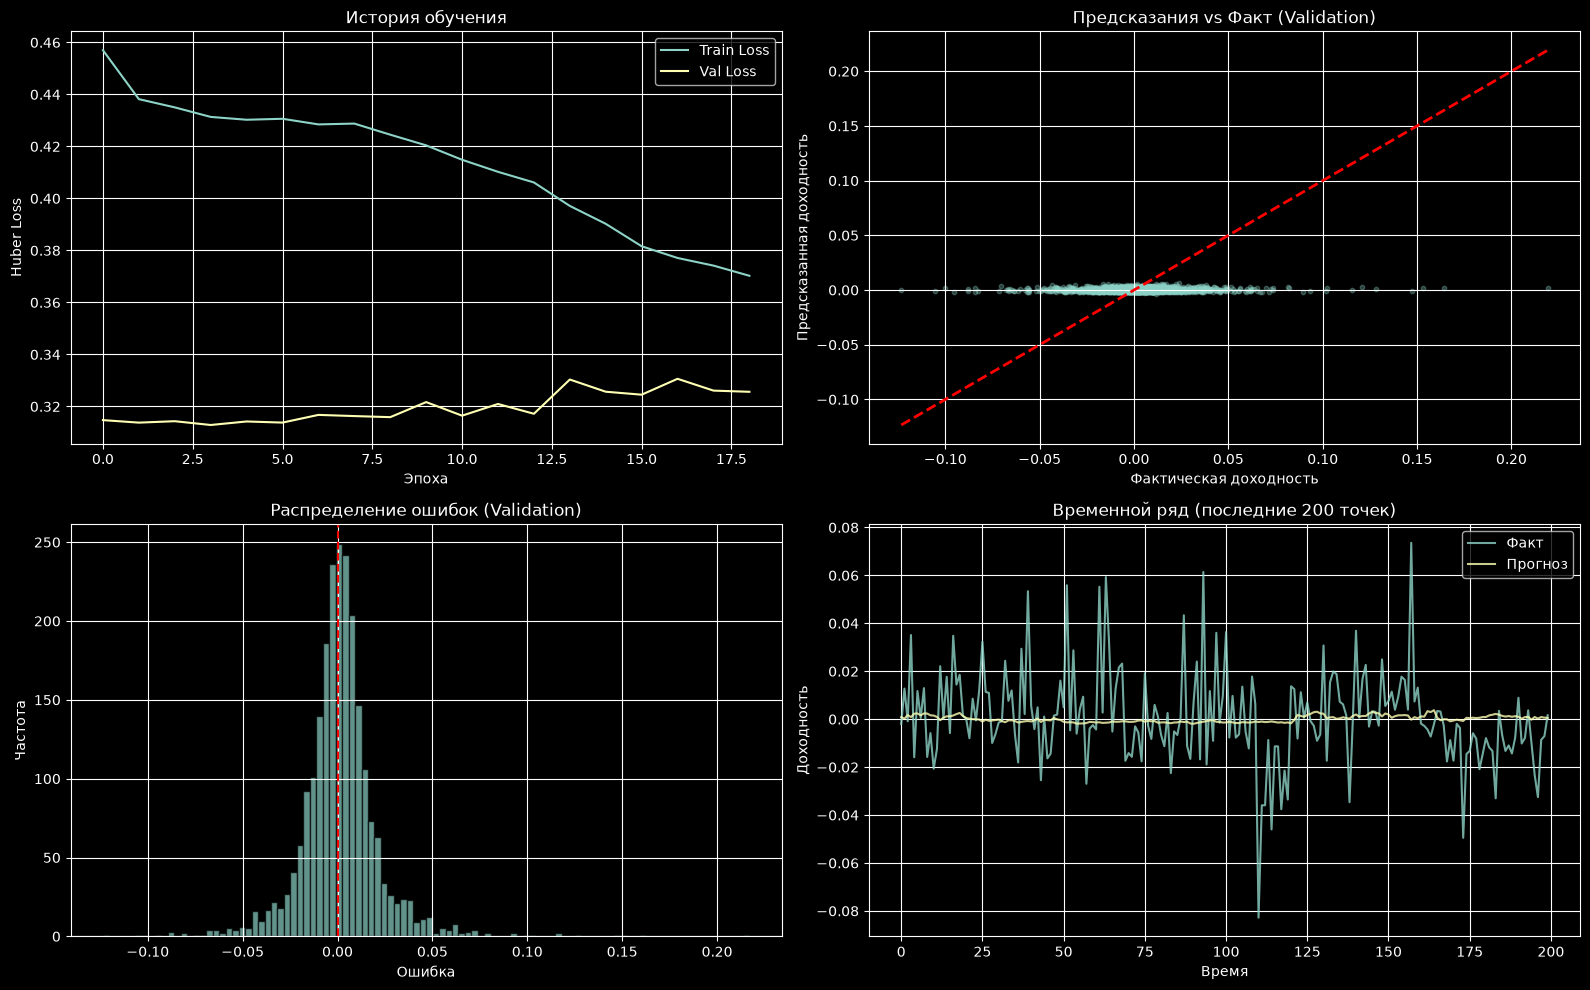

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# 1. История обучения
ax = axes[0, 0]
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('История обучения')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Huber Loss')
ax.legend()
ax.grid(True)

# 2. Предсказания vs Факт (Val)
ax = axes[0, 1]
ax.scatter(y_val_inv, y_pred_val_inv, alpha=0.3, s=10)
ax.plot([y_val_inv.min(), y_val_inv.max()], [y_val_inv.min(), y_val_inv.max()], 'r--', lw=2)
ax.set_title('Предсказания vs Факт (Validation)')
ax.set_xlabel('Фактическая доходность')
ax.set_ylabel('Предсказанная доходность')
ax.grid(True)

# 3. Распределение ошибок
ax = axes[1, 0]
errors = (y_val_inv - y_pred_val_inv).flatten()
ax.hist(errors, bins=100, alpha=0.7, edgecolor='black')
ax.set_title('Распределение ошибок (Validation)')
ax.set_xlabel('Ошибка')
ax.set_ylabel('Частота')
ax.axvline(x=0, color='r', linestyle='--')
ax.grid(True)

# 4. Временной ряд (последние 200 точек val)
ax = axes[1, 1]
n_show = 200
ax.plot(y_val_inv[-n_show:], label='Факт', alpha=0.8)
ax.plot(y_pred_val_inv[-n_show:], label='Прогноз', alpha=0.8)
ax.set_title(f'Временной ряд (последние {n_show} точек)')
ax.set_xlabel('Время')
ax.set_ylabel('Доходность')
ax.legend()
ax.grid(True)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>